In [2]:
# Import Required Libraries
import qiskit
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace, entropy
from qiskit.visualization import plot_histogram

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()
print(simulator)


Qiskit Version: 2.5.1
AerSimulator('aer_simulator')


Bell state circuit:
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
c: 2/══════════
               

Bell statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Measurement counts: {'11': 520, '00': 504}
Observed states: ['11', '00']


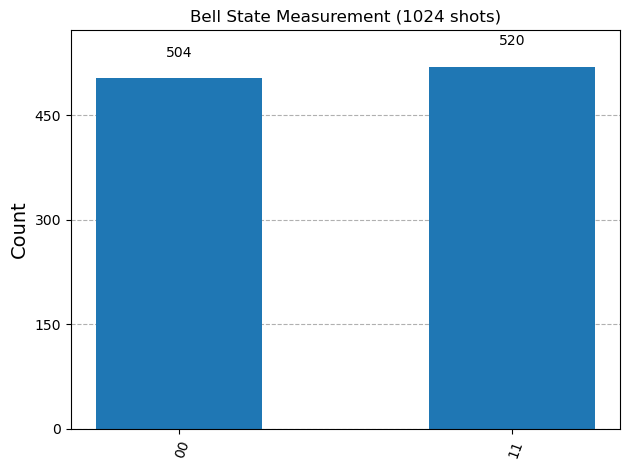

In [3]:
# Bell state |Phi+> = (|00> + |11>) / sqrt(2)

bell = QuantumCircuit(2, 2)
bell.h(0)
bell.cx(0, 1)

print("Bell state circuit:")
print(bell)

bell_state = Statevector.from_instruction(bell)
print("\nBell statevector:")
print(bell_state)

bell_measure = bell.copy()
bell_measure.measure([0, 1], [0, 1])

job = simulator.run(bell_measure, shots=1024)
counts = job.result().get_counts()

print("\nMeasurement counts:", counts)
print("Observed states:", list(counts.keys()))

plot_histogram(counts, title="Bell State Measurement (1024 shots)")
